In [1]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
C:\Users\dhima\OneDrive\Desktop\AI_sales_analytics

Files in this folder:
['.ipynb_checkpoints', 'Sales_Analytics.ipynb', 'Simple_Sales_Analytics_Dataset.csv']


In [2]:
import pandas as pd

df = pd.read_csv("Simple_Sales_Analytics_Dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product_ID,Product_Name,Category,Region,Quantity,Unit_Price,Discount,Sales,Cost,Shipping_Cost,Profit
0,ORD0001,2025-04-14,C029,Customer 26,P05,Printer,Office,East,2,11042,0.15,18771.4,15017.12,261,3493.28
1,ORD0002,2025-06-17,C007,Customer 05,P08,Notebook,Office,North,1,4741,0.10,4266.9,3223.88,268,775.02
2,ORD0003,2025-09-08,C007,Customer 20,P08,Notebook,Office,North,5,7980,0.15,33915.0,27132.00,361,6422.00
3,ORD0004,2025-09-09,C030,Customer 01,P13,USB Drive,Technology,East,1,1476,0.30,1033.2,1003.68,162,-132.48
4,ORD0005,2025-12-10,C004,Customer 04,P09,Pen Set,Office,North,2,5882,0.20,9411.2,7999.52,187,1224.68


In [3]:
print("Rows and columns:", df.shape)
print("Columns:", list(df.columns))

Rows and columns: (120, 15)
Columns: ['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Product_ID', 'Product_Name', 'Category', 'Region', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Cost', 'Shipping_Cost', 'Profit']


In [4]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Product_ID       0
Product_Name     0
Category         0
Region           0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Cost             0
Shipping_Cost    0
Profit           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

Order_ID             str
Order_Date           str
Customer_ID          str
Customer_Name        str
Product_ID           str
Product_Name         str
Category             str
Region               str
Quantity           int64
Unit_Price         int64
Discount         float64
Sales            float64
Cost             float64
Shipping_Cost      int64
Profit           float64
dtype: object

In [7]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df.dtypes

Order_ID                    str
Order_Date       datetime64[us]
Customer_ID                 str
Customer_Name               str
Product_ID                  str
Product_Name                str
Category                    str
Region                      str
Quantity                  int64
Unit_Price                int64
Discount                float64
Sales                   float64
Cost                    float64
Shipping_Cost             int64
Profit                  float64
dtype: object

In [8]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Date type:", df["Order_Date"].dtype)

Missing values: 0
Duplicate rows: 0
Date type: datetime64[us]


In [9]:
total_sales = df["Sales"].sum()
total_cost = df["Cost"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales: ₹", round(total_sales, 2))
print("Total Cost: ₹", round(total_cost, 2))
print("Total Profit: ₹", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: ₹ 2099513.25
Total Cost: ₹ 1712589.12
Total Profit: ₹ 352262.13
Total Orders: 120
Profit Margin: 16.78 %


In [10]:
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales

Order_Date
2025-01    312831.35
2025-02    113544.90
2025-03    268179.50
2025-04    156218.45
2025-05    134627.25
2025-06    134658.55
2025-07     74446.20
2025-08    202492.50
2025-09    173907.20
2025-10    157509.45
2025-11    175103.50
2025-12    195994.40
Freq: M, Name: Sales, dtype: float64

Matplotlib is building the font cache; this may take a moment.


NameError: name 'plt' is not defined

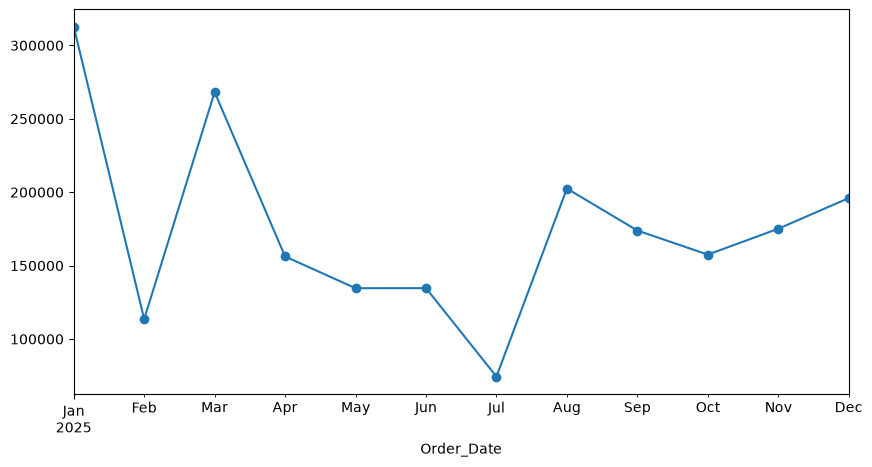

In [11]:
monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.grid(True)
plt.show()

In [12]:
plt.title("Monthly Sales Trend")


NameError: name 'plt' is not defined

In [13]:
import matplotlib.pyplot as plt

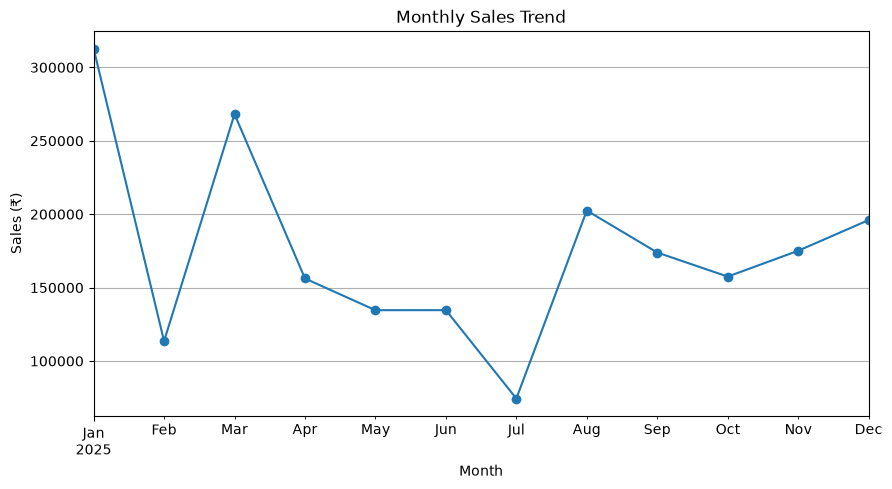

In [14]:
monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.grid(True)
plt.show()

In [ ]:
category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)
plt.show()


In [16]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

category_profit

Category
Technology    242228.07
Office        115925.20
Furniture      -5891.14
Name: Profit, dtype: float64

In [15]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology    1179224.75
Office         618785.20
Furniture      301503.30
Name: Sales, dtype: float64

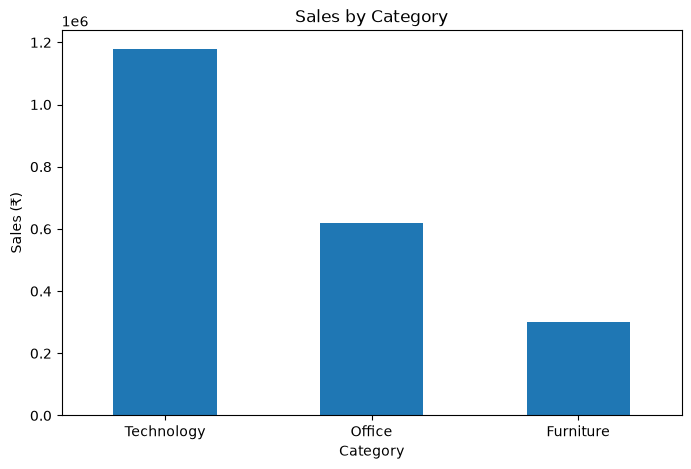

In [17]:
category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)
plt.show()

In [18]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
North    592254.90
South    568719.75
West     478899.30
East     459639.30
Name: Sales, dtype: float64

In [19]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

region_profit

Region
South    107407.75
West      88624.46
North     86619.94
East      69609.98
Name: Profit, dtype: float64

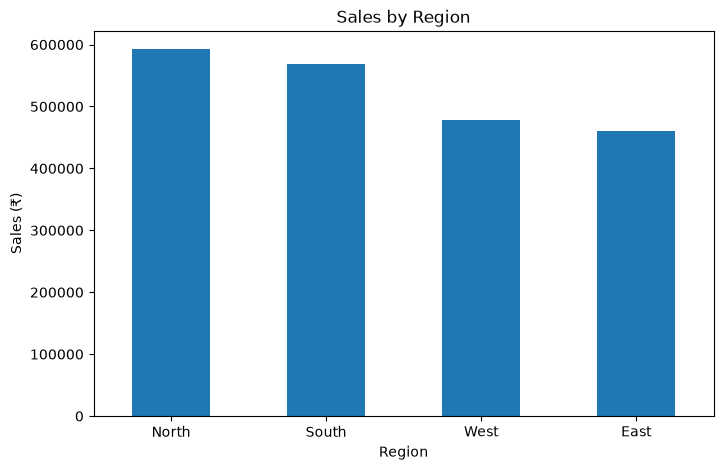

In [20]:
region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=0)
plt.show()

In [21]:
product_profit = df.groupby("Product_Name")["Profit"].sum().sort_values()

product_profit

Product_Name
Desk           -5534.06
Office Lamp    -4245.45
USB Drive        394.40
Chair           3888.37
Monitor        15723.78
Laptop         20648.66
Pen Set        23467.70
Tablet         24986.90
Headphones     25447.61
Keyboard       31197.65
Notebook       33236.13
Mouse          34203.50
Router         36479.78
Webcam         53145.79
Printer        59221.37
Name: Profit, dtype: float64

In [22]:
loss_products = product_profit[product_profit < 0]

loss_products

Product_Name
Desk          -5534.06
Office Lamp   -4245.45
Name: Profit, dtype: float64

In [23]:
top_products = product_profit.sort_values(ascending=False).head(5)

top_products

Product_Name
Printer     59221.37
Webcam      53145.79
Router      36479.78
Mouse       34203.50
Notebook    33236.13
Name: Profit, dtype: float64

In [24]:
loss_product_details = df[
    df["Product_Name"].isin(["Desk", "Office Lamp"])
]

loss_product_details[
    [
        "Product_Name",
        "Quantity",
        "Unit_Price",
        "Discount",
        "Sales",
        "Cost",
        "Shipping_Cost",
        "Profit"
    ]
]

,Product_Name,Quantity,Unit_Price,Discount,Sales,Cost,Shipping_Cost,Profit
11,Office Lamp,5,4672,0.30,16352.00,20556.80,449,-4653.80
14,Desk,5,11527,0.05,54753.25,50718.80,247,3787.45
17,Desk,2,1762,0.20,2819.20,3101.12,155,-436.92
24,Office Lamp,1,13148,0.05,12490.60,11570.24,211,709.36
30,Office Lamp,3,2784,0.00,8352.00,7349.76,273,729.24
51,Office Lamp,1,10054,0.30,7037.80,8847.52,340,-2149.72
57,Desk,1,9960,0.20,7968.00,8764.80,293,-1089.80
63,Desk,2,11120,0.30,15568.00,19571.20,200,-4203.20
72,Desk,3,6959,0.30,14613.90,18371.76,298,-4055.86
78,Office Lamp,2,3598,0.00,7196.00,6332.48,424,439.52


In [25]:
loss_analysis = loss_product_details.groupby("Product_Name").agg({
    "Quantity": "sum",
    "Sales": "sum",
    "Cost": "sum",
    "Shipping_Cost": "sum",
    "Profit": "sum",
    "Discount": "mean"
})

loss_analysis

,Quantity,Sales,Cost,Shipping_Cost,Profit,Discount
Product_Name,,,,,,
Desk,18,114456.10,118146.16,1844,-5534.06,0.171429
Office Lamp,25,117669.55,119218.00,2697,-4245.45,0.111111


In [26]:
loss_orders = df[df["Profit"] < 0]

print("Number of loss-making orders:", len(loss_orders))
print("Total loss:", round(loss_orders["Profit"].sum(), 2))

Number of loss-making orders: 24
Total loss: -20994.46


In [27]:
loss_orders[
    [
        "Order_ID",
        "Product_Name",
        "Region",
        "Quantity",
        "Discount",
        "Sales",
        "Cost",
        "Shipping_Cost",
        "Profit"
    ]
]

,Order_ID,Product_Name,Region,Quantity,Discount,Sales,Cost,Shipping_Cost,Profit
3,ORD0004,USB Drive,East,1,0.30,1033.20,1003.68,162,-132.48
5,ORD0006,Mouse,North,1,0.00,557.00,378.76,450,-271.76
10,ORD0011,Tablet,West,1,0.30,4877.60,4738.24,157,-17.64
11,ORD0012,Office Lamp,North,5,0.30,16352.00,20556.80,449,-4653.80
17,ORD0018,Desk,South,2,0.20,2819.20,3101.12,155,-436.92
21,ORD0022,Webcam,South,3,0.20,2100.00,1785.00,450,-135.00
29,ORD0030,Laptop,South,1,0.30,7044.80,6843.52,462,-260.72
31,ORD0032,Keyboard,West,1,0.30,5103.00,4957.20,261,-115.20
37,ORD0038,Notebook,North,1,0.20,990.40,841.84,288,-139.44
38,ORD0039,Chair,South,1,0.15,7295.55,7553.04,489,-746.49


In [28]:
customer_sales = (
    df.groupby(["Customer_ID", "Customer_Name"])["Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(5)

Customer_ID  Customer_Name
C015         Customer 24      58915.00
C009         Customer 27      57184.00
C007         Customer 12      54857.75
C021         Customer 10      54753.25
C003         Customer 10      53869.75
Name: Sales, dtype: float64

In [29]:
customer_profit = (
    df.groupby(["Customer_ID", "Customer_Name"])["Profit"]
    .sum()
    .sort_values(ascending=False)
)

customer_profit.head(5)

Customer_ID  Customer_Name
C015         Customer 24      18516.80
C007         Customer 12      15163.15
C003         Customer 10      15039.35
C019         Customer 10      14223.32
C016         Customer 22      12239.40
Name: Profit, dtype: float64

In [30]:
customer_orders = (
    df.groupby(["Customer_ID", "Customer_Name"])["Order_ID"]
    .nunique()
    .sort_values(ascending=False)
)

customer_orders.head(5)

Customer_ID  Customer_Name
C014         Customer 25      3
C008         Customer 14      2
C014         Customer 03      2
C007         Customer 11      2
C023         Customer 03      2
Name: Order_ID, dtype: int64

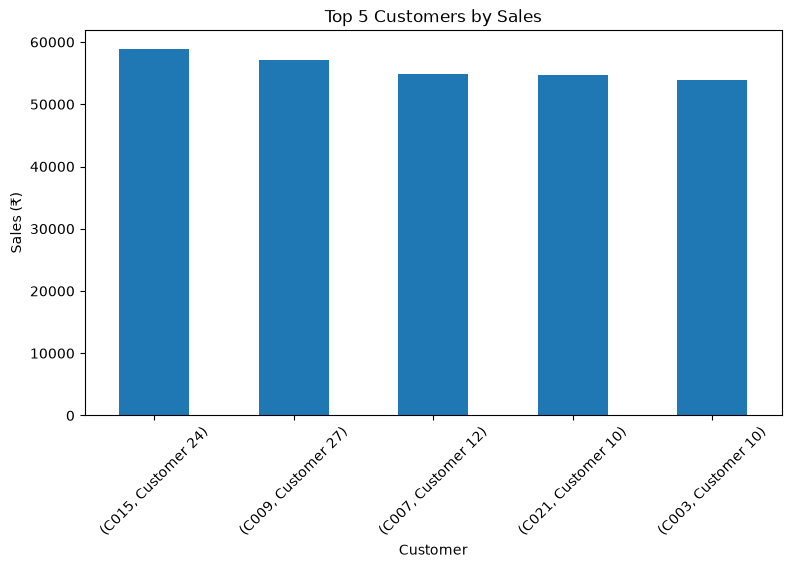

In [31]:
top_customer_sales = customer_sales.head(5)

top_customer_sales.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Top 5 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.show()

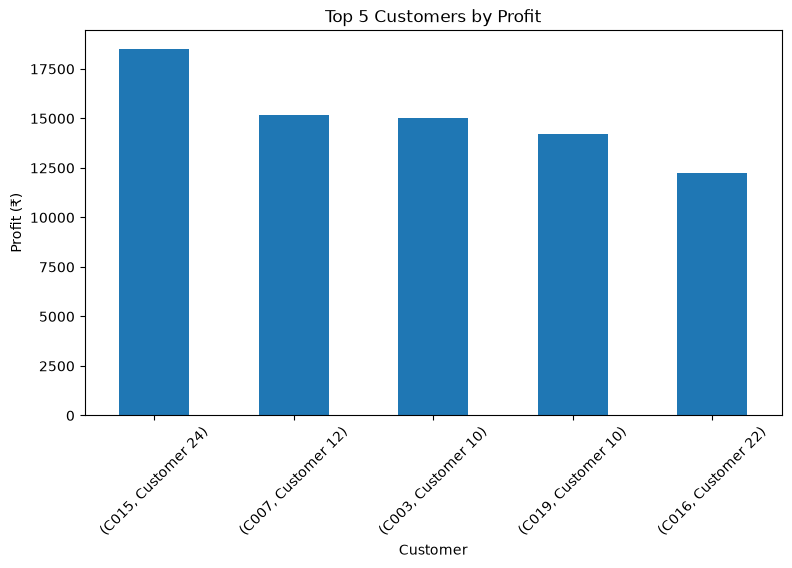

In [32]:
top_customer_profit = customer_profit.head(5)

top_customer_profit.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Top 5 Customers by Profit")
plt.xlabel("Customer")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=45)
plt.show()

In [33]:
monthly_df = monthly_sales.reset_index()

monthly_df.columns = ["Month", "Sales"]

monthly_df["Month_Number"] = range(1, len(monthly_df) + 1)

monthly_df

,Month,Sales,Month_Number
0,2025-01,312831.35,1
1,2025-02,113544.90,2
2,2025-03,268179.50,3
3,2025-04,156218.45,4
4,2025-05,134627.25,5
5,2025-06,134658.55,6
6,2025-07,74446.20,7
7,2025-08,202492.50,8
8,2025-09,173907.20,9
9,2025-10,157509.45,10


In [34]:
from sklearn.linear_model import LinearRegression

X = monthly_df[["Month_Number"]]
y = monthly_df["Sales"]

model = LinearRegression()

model.fit(X, y)

print("Model trained successfully!")

Model trained successfully!


In [35]:
future_months = [[13], [14], [15]]

future_predictions = model.predict(future_months)

for month, prediction in zip(["Jan 2026", "Feb 2026", "Mar 2026"], future_predictions):
    print(month, "Predicted Sales: ₹", round(prediction, 2))

Jan 2026 Predicted Sales: ₹ 146003.93
Feb 2026 Predicted Sales: ₹ 141549.24
Mar 2026 Predicted Sales: ₹ 137094.55


C:\Users\dhima\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
forecast_df = pd.DataFrame({
    "Month": ["Jan 2026", "Feb 2026", "Mar 2026"],
    "Predicted_Sales": future_predictions
})

forecast_df["Predicted_Sales"] = forecast_df["Predicted_Sales"].round(2)

forecast_df

,Month,Predicted_Sales
0,Jan 2026,146003.93
1,Feb 2026,141549.24
2,Mar 2026,137094.55


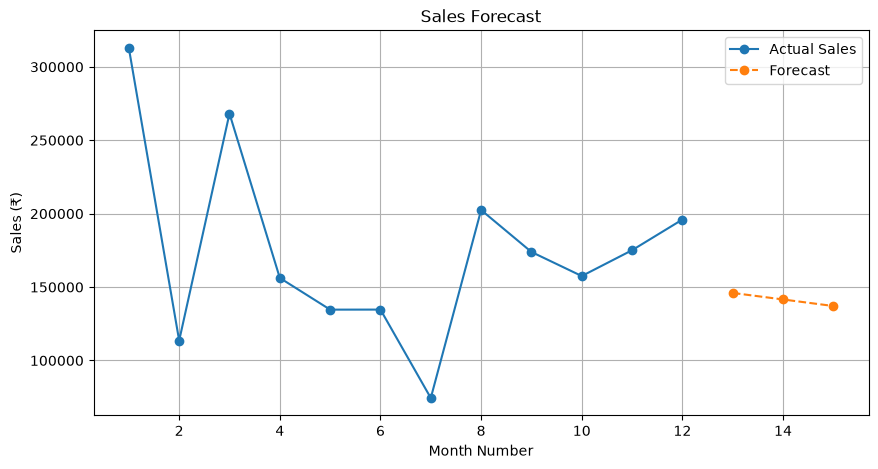

In [37]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_df["Month_Number"],
    monthly_df["Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    [13, 14, 15],
    future_predictions,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Sales Forecast")
plt.xlabel("Month Number")
plt.ylabel("Sales (₹)")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

df[["Product_Name", "Sales", "Profit", "Profit_Margin"]].head()

,Product_Name,Sales,Profit,Profit_Margin
0,Printer,18771.4,3493.28,18.609587
1,Notebook,4266.9,775.02,18.163538
2,Notebook,33915.0,6422.00,18.935574
3,USB Drive,1033.2,-132.48,-12.822300
4,Pen Set,9411.2,1224.68,13.013006


In [39]:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.strftime("%b")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product_ID,Product_Name,Category,Region,Quantity,Unit_Price,Discount,Sales,Cost,Shipping_Cost,Profit,Profit_Margin,Year,Month,Month_Name
0,ORD0001,2025-04-14,C029,Customer 26,P05,Printer,Office,East,2,11042,0.15,18771.4,15017.12,261,3493.28,18.609587,2025,4,Apr
1,ORD0002,2025-06-17,C007,Customer 05,P08,Notebook,Office,North,1,4741,0.10,4266.9,3223.88,268,775.02,18.163538,2025,6,Jun
2,ORD0003,2025-09-08,C007,Customer 20,P08,Notebook,Office,North,5,7980,0.15,33915.0,27132.00,361,6422.00,18.935574,2025,9,Sep
3,ORD0004,2025-09-09,C030,Customer 01,P13,USB Drive,Technology,East,1,1476,0.30,1033.2,1003.68,162,-132.48,-12.822300,2025,9,Sep
4,ORD0005,2025-12-10,C004,Customer 04,P09,Pen Set,Office,North,2,5882,0.20,9411.2,7999.52,187,1224.68,13.013006,2025,12,Dec


In [40]:
df.to_csv("Sales_Analytics_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [41]:
forecast_df.to_csv("Sales_Forecast.csv", index=False)

forecast_df

,Month,Predicted_Sales
0,Jan 2026,146003.93
1,Feb 2026,141549.24
2,Mar 2026,137094.55


In [42]:
forecast_df

,Month,Predicted_Sales
0,Jan 2026,146003.93
1,Feb 2026,141549.24
2,Mar 2026,137094.55


In [43]:
forecast_df.to_csv("Sales_Forecast.csv", index=False)